In [78]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

resistance = 10000
# in Ω
capacitance = 10
# in uF
data = pd.read_csv("D:\Capacitance-Discharge Project\scope-data.csv", sep = ',')

Capacitor_A_Avg = (data["Capacitor A max"]+data["Capacitor A min"])/2
Capacitor_V_Avg = (data["Capacitor V max"]+data["Capacitor V min"])/2

data['Capacitor_A_Avg'] = Capacitor_A_Avg
data['Capacitor_V_Avg'] = Capacitor_V_Avg
clean_data_1 = data.drop(["Capacitor V min", "Capacitor V max", "Capacitor A min", "Capacitor A max"], axis = 1)
clean_data_2 = clean_data_1[clean_data_1["time"]>7.840]
clean_data_2

# Discharge filter
# Clean values between 0.25V to 4.75V
discharge = clean_data_2[(clean_data_2["Capacitor_V_Avg"]<4.5) & 
                         (clean_data_2["Capacitor_V_Avg"]>0.5)].copy()

# Why current is negative?
# During charging, current flows onto the capacitor, so it is +
# During discharging, current flows from capacitor to circuit, so it is -

# Reset time to initial t is 0: 
# No need to create another column and deleting the old one
discharge = discharge.assign(
    time = discharge["time"] - discharge["time"].min()
)

Text(0, 0.5, 'Vc')

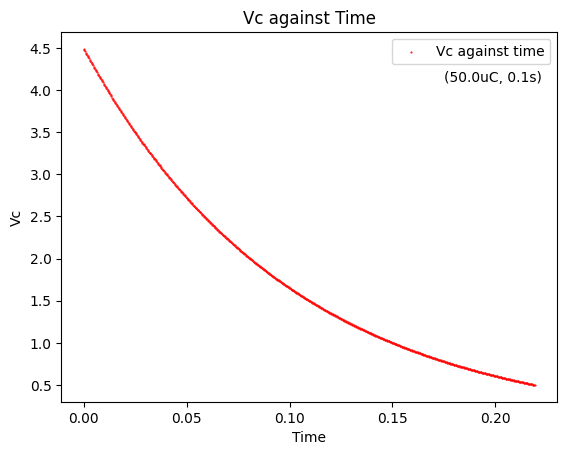

In [82]:
v_values = np.array(discharge['Capacitor_V_Avg'])
time = np.array(discharge['time'])

# Plotting
fig,ax = plt.subplots()
ax.scatter(time,v_values, s = 0.25, label = "Vc against time", color = 'red', linewidths = 1)
ax.legend()


# Values of Data:
voltage_peak = 5
charge = capacitance*voltage_peak
tau_theory = resistance*capacitance*10**-6
ax.annotate(
    text = f"({charge:.1f}uC, {tau_theory:.1f}s)",
    xy = (0.175,4.1),
)

# data:
ax.set_title("Vc against Time")
ax.set_xlabel("Time")
ax.set_ylabel("Vc")



In [ ]:
# Things to do:
# Model accuracy
# Fault detection
# Export

,time,Capacitor_A_Avg,Capacitor_V_Avg,ln(V_Avg/Vo)
615,0.00000,-0.000449,4.486870,-0.108283
616,0.00032,-0.000447,4.472535,-0.111483
617,0.00064,-0.000446,4.458246,-0.114683
618,0.00096,-0.000444,4.444002,-0.117883
619,0.00128,-0.000443,4.429804,-0.121083
...,...,...,...,...
1296,0.21792,-0.000051,0.507620,-2.287461
1297,0.21824,-0.000051,0.505998,-2.290661
1298,0.21856,-0.000050,0.504381,-2.293861
1299,0.21888,-0.000050,0.502770,-2.297061


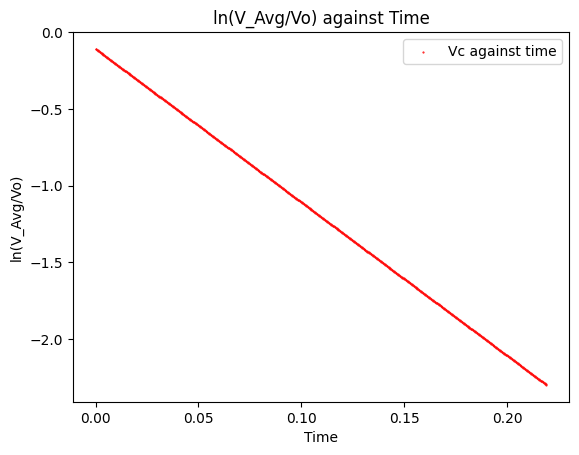

In [ ]:
# import math
# math expects only a single number, not a list, use np instead
# plot ln ... against t
discharge["ln(V_Avg/Vo)"] = np.log(discharge["Capacitor_V_Avg"]/voltage_peak)
v2_values = np.array(discharge['ln(V_Avg/Vo)'])

# Plotting
fig,ax = plt.subplots()
ax.scatter(time, v2_values, s = 0.25, label = "Vc against time", color = 'red', linewidths = 1)
ax.legend()


# Values of Data:
voltage_peak = 5
charge = capacitance*voltage_peak
time_constant = resistance*capacitance*10**-6

# data:
ax.set_title("ln(V_Avg/Vo) against Time")
ax.set_xlabel("Time")
ax.set_ylabel("ln(V_Avg/Vo)")

discharge.copy()


In [96]:
# Gradient:

from sklearn.linear_model import LinearRegression
model = LinearRegression()

x = np.array(time).reshape(-1, 1)
y = np.array(v2_values)

model.fit(x, y)
gradient = model.coef_[0]

tau_exp = -1/gradient

# Percentage error:
tau_calc = 100*(tau_exp-tau_theory)/tau_theory
print("Percentage Error of Tau:",tau_calc.round(6),"%")


Percentage Error of Tau: 0.001 %


In [ ]:
# Finding Half-Live (theory vs experimental), percentage error

# Method 1: 
# Use tau = t(1/2)/ln2
v_values = np.array(discharge['Capacitor_V_Avg'])
time = np.array(discharge['time'])

t_half_life = tau_exp*np.log(2)
discharge

# Method 2: Interpolation
# Since data no direct 4.5 to 2.25, can use regression, and move to find t (subject)

def time_voltage(v):
    return np.log(v/voltage_peak)/gradient

t1 = time_voltage(4.5)
t2 = time_voltage(2.25)

half_life = t2-t1

if t_half_life == half_life:
    print("Percentage Error is 0%")
else:
    pass

# same half life

Percentage Error is 0%


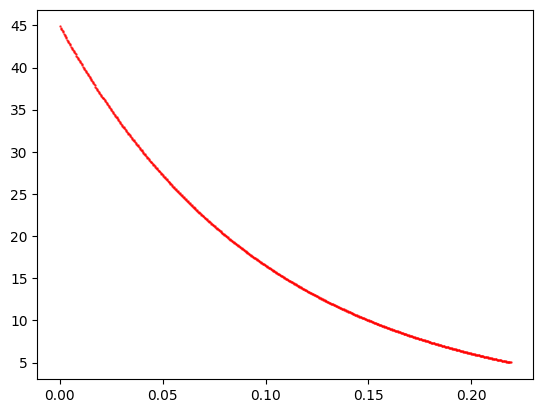

In [128]:
# Plot charge over time
# Q = CV
charge_with_time = v_values*capacitance

fig,ax = plt.subplots()
ax.scatter(time,charge_with_time, s = 0.5, alpha = 0.75, c = 'red')




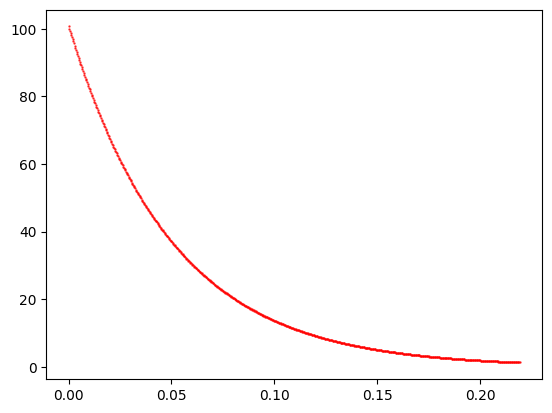

In [127]:
energy_with_time = 0.5*capacitance*v_values**2
fig,ax = plt.subplots()
ax.scatter(time,energy_with_time, s = 0.5, alpha = 0.75, c = 'red')

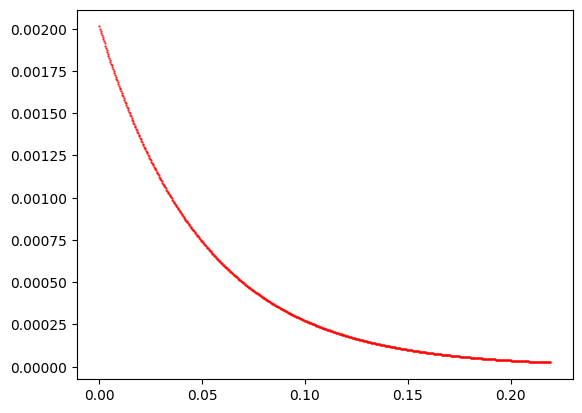

In [ ]:
# Plot I = Io * e^t/RC
discharge
# Finding Power
power = v_values**2/resistance
# Finding current
fig,ax = plt.subplots()
ax.scatter(time,power, s = 0.5, alpha = 0.75, c = 'red')




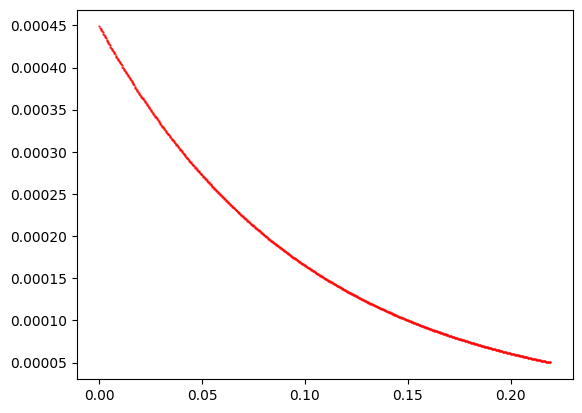

In [ ]:
# Finding Current
current_peak = voltage_peak/resistance
current_values = np.array(discharge["Capacitor_A_Avg"])


fig,ax = plt.subplots()
ax.scatter(time,-current_values, s = 0.5, alpha = 0.75, c = 'red')


In [139]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Make a safe copy
temp = discharge.copy()

# Reset time
temp["time_reset"] = temp["time"] - temp["time"].min()

# Remove invalid voltage values
temp = temp[temp["Capacitor_V_Avg"] > 0].copy()

# Fit ln(V) against time
temp["ln_V"] = np.log(temp["Capacitor_V_Avg"])

X = temp[["time_reset"]]
y = temp["ln_V"]

model = LinearRegression()
model.fit(X, y)

slope = model.coef_[0]
intercept = model.intercept_

# Predicted ln(V)
temp["ln_V_pred"] = model.predict(X)

# Convert back to voltage
temp["V_pred"] = np.exp(temp["ln_V_pred"])

# Actual voltage
actual = temp["Capacitor_V_Avg"]
predicted = temp["V_pred"]

# Accuracy metrics
mae = mean_absolute_error(actual, predicted)
rmse = np.sqrt(mean_squared_error(actual, predicted))
r2 = r2_score(actual, predicted)

# Normalised RMSE, easier to understand
voltage_peak = 5
nrmse = rmse / voltage_peak * 100

print("MAE:", mae, "V")
print("RMSE:", rmse, "V")
print("R²:", r2)
print("Normalised RMSE:", nrmse, "%")

MAE: 8.540301604878938e-15 V
RMSE: 1.186781445461867e-14 V
R²: 1.0
Normalised RMSE: 2.373562890923734e-13 %


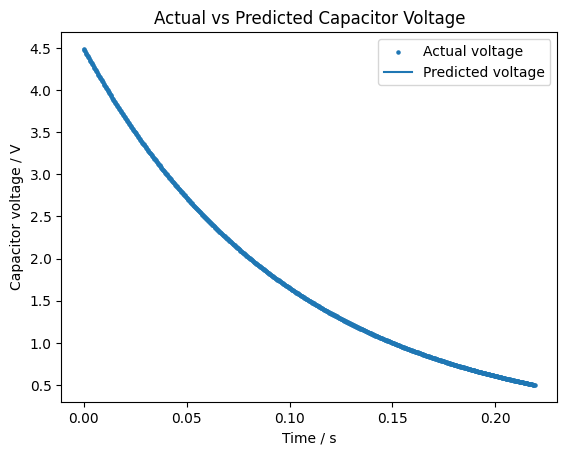

In [140]:
fig, ax = plt.subplots()

ax.scatter(
    temp["time_reset"],
    temp["Capacitor_V_Avg"],
    s=5,
    label="Actual voltage"
)

ax.plot(
    temp["time_reset"],
    temp["V_pred"],
    label="Predicted voltage"
)

ax.set_title("Actual vs Predicted Capacitor Voltage")
ax.set_xlabel("Time / s")
ax.set_ylabel("Capacitor voltage / V")
ax.legend()

plt.show()

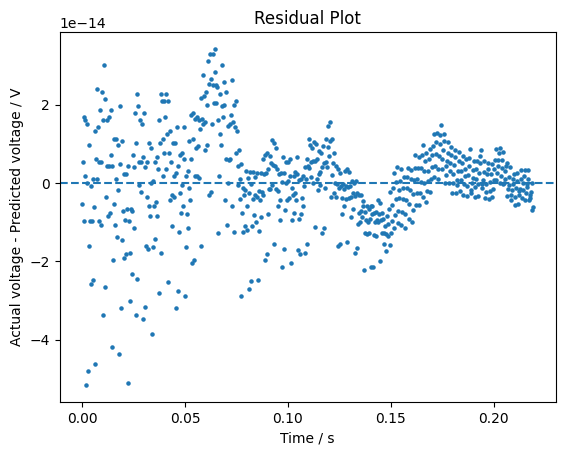

In [141]:
temp["residual"] = temp["Capacitor_V_Avg"] - temp["V_pred"]

fig, ax = plt.subplots()

ax.scatter(
    temp["time_reset"],
    temp["residual"],
    s=5
)

ax.axhline(0, linestyle="--")

ax.set_title("Residual Plot")
ax.set_xlabel("Time / s")
ax.set_ylabel("Actual voltage - Predicted voltage / V")

plt.show()

In [142]:
# Experimental values from model
tau_est = -1 / slope
C_est = tau_est / resistance

# If your capacitance variable is in microfarads, for example capacitance = 10
C_true = capacitance * 1e-6

C_error_pct = abs(C_est - C_true) / C_true * 100

print("Estimated tau:", tau_est, "s")
print("Estimated capacitance:", C_est, "F")
print("Estimated capacitance:", C_est * 1e6, "uF")
print("True capacitance:", C_true * 1e6, "uF")
print("Capacitance percentage error:", C_error_pct, "%")

Estimated tau: 0.10000099997916453 s
Estimated capacitance: 1.0000099997916454e-05 F
Estimated capacitance: 10.000099997916454 uF
True capacitance: 10.0 uF
Capacitance percentage error: 0.000999979164550231 %


In [143]:
faults = []

# Thresholds
cap_error_limit = 10       # percent
nrmse_limit = 3            # percent of 5V
r2_limit = 0.995

if C_error_pct > cap_error_limit:
    faults.append("Capacitance mismatch")

if nrmse > nrmse_limit:
    faults.append("High voltage prediction error")

if r2 < r2_limit:
    faults.append("Poor exponential fit")

if len(faults) == 0:
    status = "Normal"
else:
    status = "Faulty"

print("Circuit status:", status)

if faults:
    print("Detected issues:")
    for fault in faults:
        print("-", fault)
else:
    print("No major fault detected.")

Circuit status: Normal
No major fault detected.


In [144]:
summary = pd.DataFrame({
    "Metric": [
        "Estimated tau",
        "Estimated capacitance",
        "True capacitance",
        "Capacitance error",
        "MAE",
        "RMSE",
        "Normalised RMSE",
        "R²",
        "Status"
    ],
    "Value": [
        tau_est,
        C_est * 1e6,
        C_true * 1e6,
        C_error_pct,
        mae,
        rmse,
        nrmse,
        r2,
        status
    ],
    "Unit": [
        "s",
        "uF",
        "uF",
        "%",
        "V",
        "V",
        "%",
        "",
        ""
    ]
})

summary

,Metric,Value,Unit
0,Estimated tau,0.100001,s
1,Estimated capacitance,10.0001,uF
2,True capacitance,10.0,uF
3,Capacitance error,0.001,%
4,MAE,0.0,V
5,RMSE,0.0,V
6,Normalised RMSE,0.0,%
7,R²,1.0,
8,Status,Normal,
